# Every delay, every variable

Each datapoint is one **delayed line-hour**: an hour in which at least one delay incident touched that line (since `config.TRAIN_START`).
Each datapoint carries all 24 model features, computed as the model would have seen them **1 hour before** (horizon = 1).

No chart can literally show 24 dimensions, so this notebook uses two views:

1. **Parallel coordinates**: one vertical axis per variable; each delay is a line crossing every axis. Drag on an axis to filter (e.g. only rush hour, only rain). Click an axis title and drag to reorder.
2. **PCA projection**: squashes all numeric variables into 2D so similar delays land near each other.


In [1]:
import sys
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), Path.cwd().parent] if (p / "ml").exists())
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from ml import config
from ml.dataset import _grid, load_data
from ml.features import FEATURES, build_features
from ml.plotting import FIGURES_DIR, GRAY, SEQ_CMAP, SERIES, TEXT_2, setup, show

setup()
data = load_data()
rows = _grid(data, config.TRAIN_START, None).assign(horizon=1)
rows = build_features(rows, data.counts, data.weather, data.line_profile)
rows["line_code"] = rows["line"].cat.codes      # plotting needs numbers, not letters

delays = rows[rows["label"] == 1]
quiet = rows[rows["label"] == 0]
print(f"{len(rows):,} line-hours, {len(delays):,} with a delay ({len(delays) / len(rows):.1%}), "
      f"{rows['target_ts'].min():%Y-%m-%d} to {rows['target_ts'].max():%Y-%m-%d}")

1,080,816 line-hours, 181,848 with a delay (16.8%), 2021-01-03 to 2026-08-11


## 1. Parallel coordinates

`N_POINTS` delays are drawn at random (`None` = every delay; ~150k lines is slow in a browser).
`COMPARE = True` adds the same number of **non-delay** hours in gray, so you can see where delays differ from normal hours.

The full chart is also saved to `reports/figures/delays_parallel.html`, which opens in any browser.

In [2]:
N_POINTS = 5_000
COMPARE = True
COLOR_BY = "hour"      # any column, e.g. "line_code", "line_delays_24h", "precipitation"

sample = delays if N_POINTS is None else delays.sample(min(N_POINTS, len(delays)), random_state=0)
if COMPARE:
    sample = pd.concat([quiet.sample(len(sample), random_state=0), sample])

axes = ["line_code"] + [f for f in FEATURES if f not in ("line", "horizon")]
dims = []
for f in axes:
    d = dict(label=f, values=sample[f])
    if f == "line_code":
        d.update(label="line", tickvals=list(range(len(config.LINES))), ticktext=config.LINES)
    dims.append(d)

if COMPARE:
    color = dict(color=sample["label"], colorscale=[[0, "#d9d7d2"], [1, SERIES[7]]], showscale=False)
    title = f"{N_POINTS:,} delayed line-hours (red) vs {N_POINTS:,} normal line-hours (gray)"
else:
    color = dict(color=sample[COLOR_BY], colorscale="Viridis", showscale=True,
                 colorbar=dict(title=COLOR_BY))
    title = f"{len(sample):,} delayed line-hours, colored by {COLOR_BY}"

fig = go.Figure(go.Parcoords(line=color, dimensions=dims, labelangle=-35, labelside="bottom"))
fig.update_layout(title=title, height=620, margin=dict(l=60, r=60, t=70, b=140),
                  paper_bgcolor="#fcfcfb", plot_bgcolor="#fcfcfb")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig.write_html(FIGURES_DIR / "delays_parallel.html", include_plotlyjs="cdn")
fig.show()

## 2. How each variable differs on delay hours

Parallel coordinates are hard to read with thousands of lines. This is the same comparison as numbers:
the average of each variable on delayed hours vs normal hours, and the ratio.

In [3]:
num = [f for f in FEATURES if f not in ("line", "horizon")]
cmp = pd.DataFrame({"delay_hours": delays[num].mean(), "normal_hours": quiet[num].mean()})
cmp["ratio"] = cmp["delay_hours"] / cmp["normal_hours"].replace(0, np.nan)
cmp.sort_values("ratio", ascending=False).round(3)

,delay_hours,normal_hours,ratio
line_delays_1h,0.462,0.138,3.348
line_delays_3h,1.092,0.474,2.303
line_delays_6h,1.892,1.007,1.879
line_delays_24h,6.352,4.272,1.487
sys_delays_1h,5.498,3.983,1.380
sys_delays_3h,15.489,12.152,1.275
sys_delays_6h,29.437,24.613,1.196
snow_24h,0.163,0.139,1.178
hour,12.736,11.250,1.132
snowfall,0.006,0.006,1.101


## 3. PCA: all numeric variables squashed into 2D

Each variable is rescaled to the same range, then PCA finds the two directions along which the delays vary most.
Left: delays only, colored by hour of day. Right: every line-hour, binned into hexagons; the color is the share of line-hours in that hexagon that had a delay (overall: ~17%).
The table below says what each axis means: variables with large numbers in a column push points along that axis.

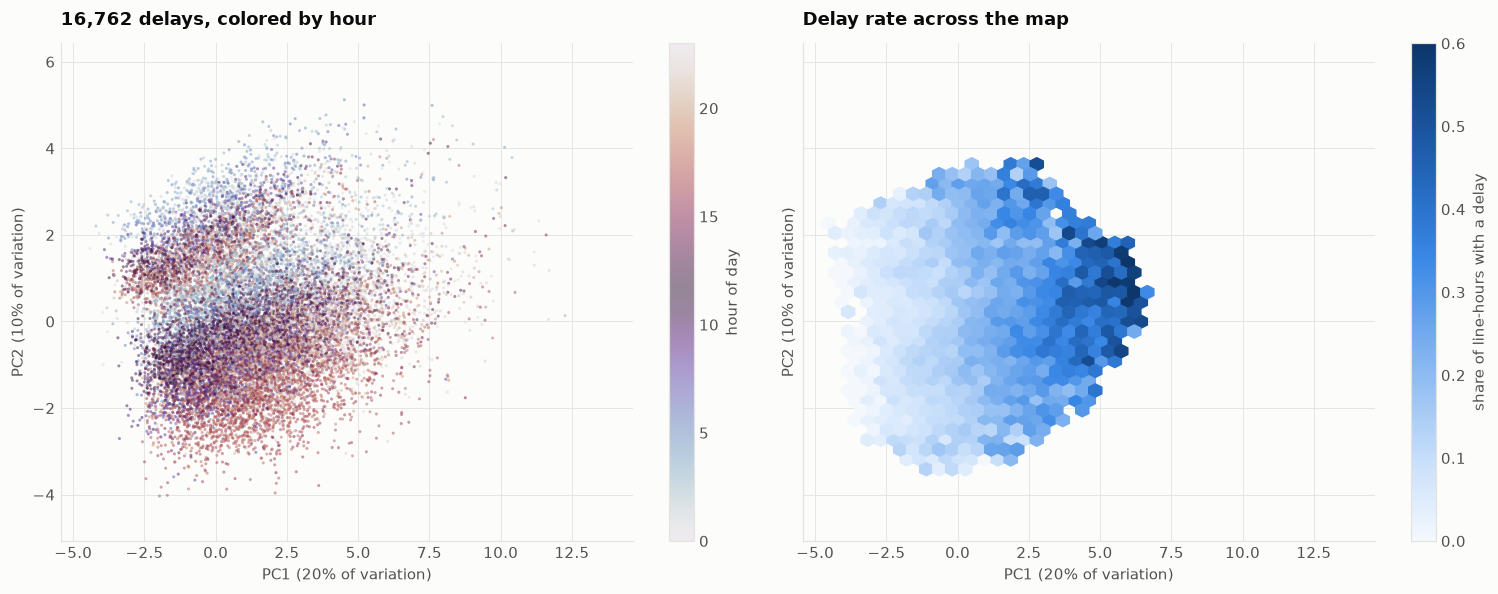

These two axes capture 30% of the variation across 22 variables.


,PC1,PC2
is_weekend,-0.16,0.49
dow,-0.12,0.47
line_delays_6h,0.36,0.21
line_delays_3h,0.36,0.20
is_rush,0.03,-0.38
sys_delays_3h,0.35,-0.11
hours_since_line_delay,-0.32,-0.16
sys_delays_6h,0.35,-0.08


In [4]:
num = [f for f in FEATURES if f not in ("line", "horizon")]
pts = rows.sample(100_000, random_state=0)      # a random sample, so delay rates stay true
scaler = StandardScaler().fit(pts[num])
pca = PCA(2, random_state=0).fit(scaler.transform(pts[num]))
xy = pca.transform(scaler.transform(pts[num]))
is_delay = pts["label"].to_numpy() == 1
ev = pca.explained_variance_ratio_

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True, sharey=True)
sc = a1.scatter(xy[is_delay, 0], xy[is_delay, 1], c=pts.loc[is_delay, "hour"], cmap="twilight",
                s=4, alpha=0.5, linewidths=0)
fig.colorbar(sc, ax=a1, label="hour of day")
a1.set_title(f"{is_delay.sum():,} delays, colored by hour")
hb = a2.hexbin(xy[:, 0], xy[:, 1], C=pts["label"], reduce_C_function=np.mean, gridsize=40,
               mincnt=20, cmap=SEQ_CMAP, vmin=0, vmax=0.6)
fig.colorbar(hb, ax=a2, label="share of line-hours with a delay")
a2.set_title("Delay rate across the map")
for a in (a1, a2):
    a.set(xlabel=f"PC1 ({ev[0]:.0%} of variation)", ylabel=f"PC2 ({ev[1]:.0%} of variation)")
show(fig, "delays_pca")
print(f"These two axes capture {ev.sum():.0%} of the variation across {len(num)} variables.")
load = pd.DataFrame(pca.components_.T, index=num, columns=["PC1", "PC2"])
load.loc[(load ** 2).sum(axis=1).sort_values(ascending=False).index[:8]].round(2)